## Introducción

En este notebook, realizaremos un análisis exhaustivo del conjunto de datos **Wine** para una tarea de **clasificación binaria**. Utilizaremos el modelo de **Regresión Logística** para construir tres modelos distintos y seleccionaremos el mejor basado en diversas métricas de desempeño. Además, implementaremos un pipeline de preprocesamiento robusto que incluye manejo de valores nulos, duplicados, transformación de variables, codificación de variables categóricas (si las hubiera) y balanceo de clases.



---

## Importación de Librerías

Primero, importaremos todas las librerías necesarias para nuestro análisis.


In [2]:
# Importación de librerías básicas
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Manejo de desequilibrio de clases
from imblearn.over_sampling import SMOTE

# Selección de características
from sklearn.feature_selection import SelectKBest, f_classif

# Métricas de evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

---

## Carga y Preparación del Conjunto de Datos

Cargaremos el conjunto de datos `wine` de scikit-learn y lo prepararemos para una tarea de clasificación binaria.


In [3]:
# Carga del conjunto de datos
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# Convertimos el problema a una clasificación binaria (clase 0 vs clases 1 y 2)
y_binary = np.where(y == 0, 0, 1)

# Añadimos la variable objetivo al dataframe
data = X.copy()
data['Target'] = y_binary

In [4]:
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



### Verificación de Valores Nulos

Es esencial verificar si existen valores nulos en el conjunto de datos para manejar adecuadamente cualquier inconsistencia.


In [5]:
null_counts = data.isnull().sum()
print("Conteo de valores nulos por columna:")
print(null_counts)

Conteo de valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64



**Observación:**

- No hay valores nulos en el conjunto de datos. Sin embargo, incluimos el manejo de valores nulos en el pipeline para asegurar la robustez del código ante futuras modificaciones de los datos.

### Verificación de Duplicados

Verificaremos si existen filas duplicadas en el conjunto de datos.


In [6]:
duplicate_rows = data.duplicated().sum()
print(f"Número de filas duplicadas: {duplicate_rows}")

Número de filas duplicadas: 0



**Observación:**

- No se encontraron filas duplicadas en el conjunto de datos. Si hubiera duplicados, optaríamos por eliminarlos para evitar sesgos en el modelo.



---

## Análisis Exploratorio de Datos (EDA)

### Análisis Univariado

Examinaremos la distribución de cada característica individualmente para identificar posibles sesgos y la necesidad de transformaciones.


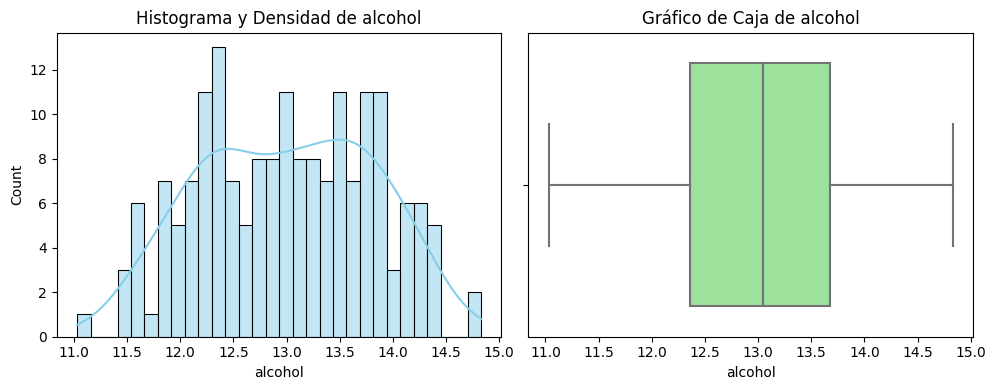

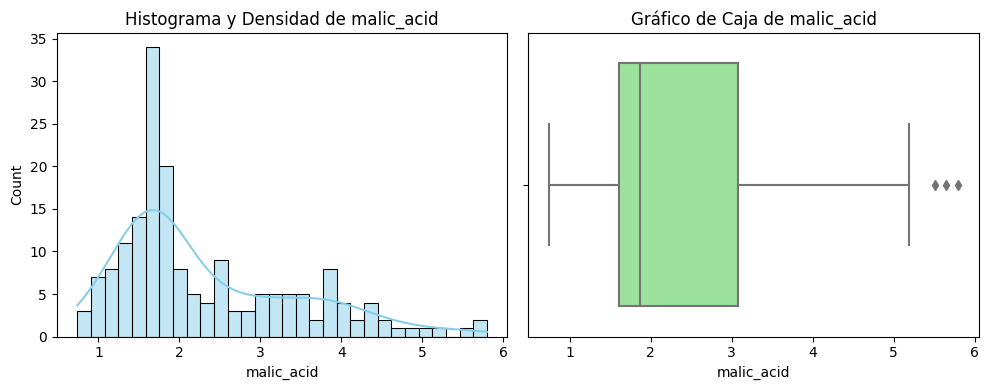

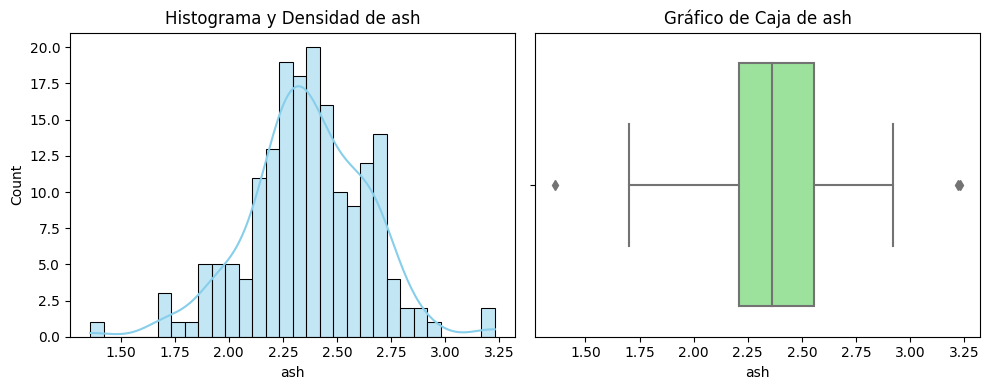

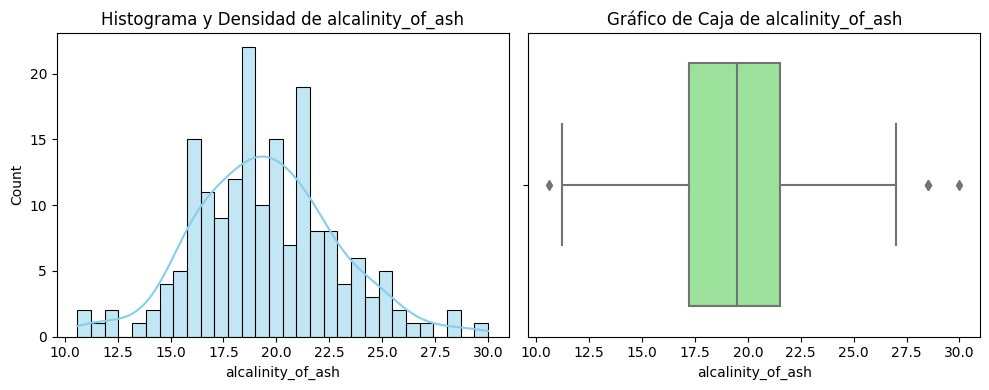

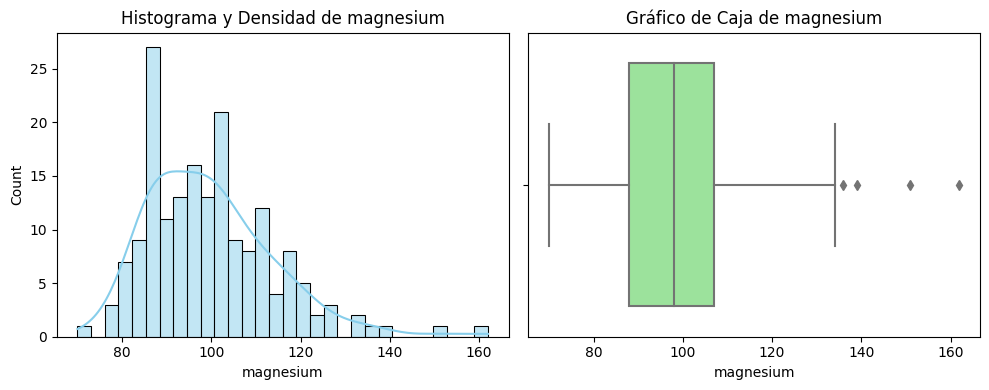

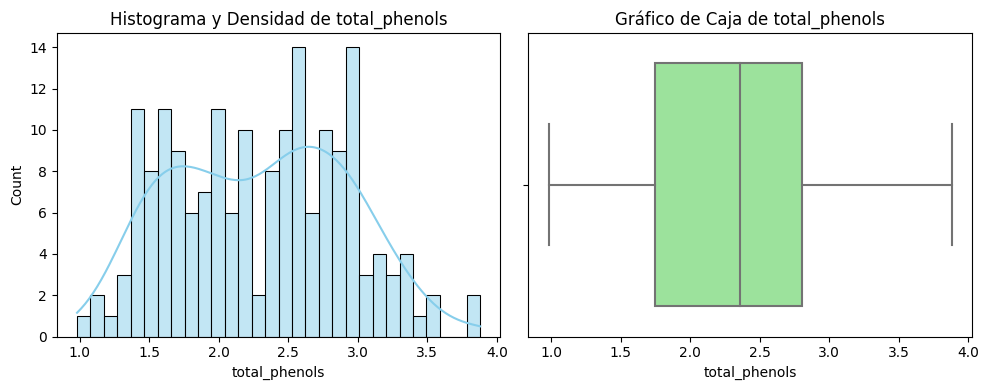

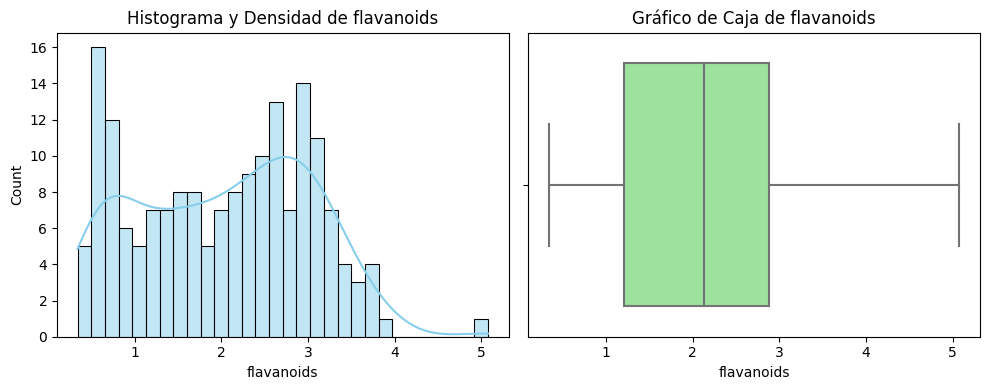

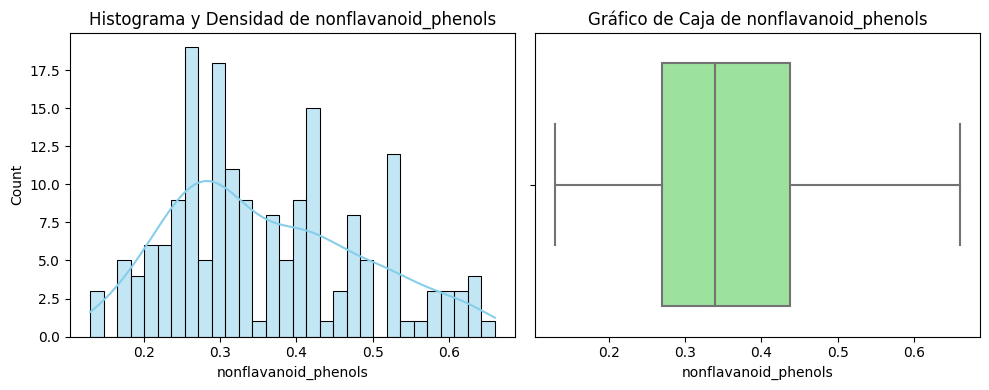

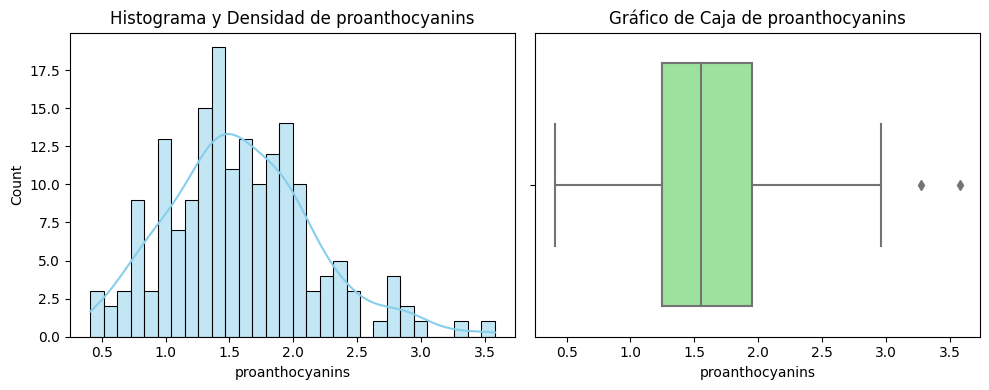

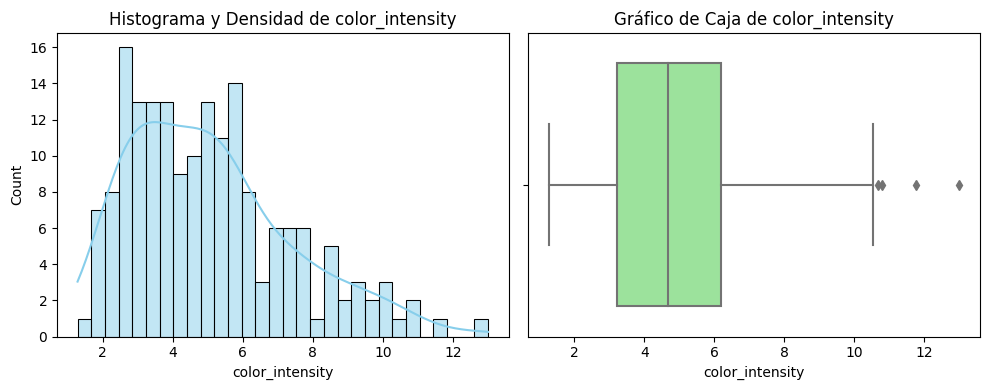

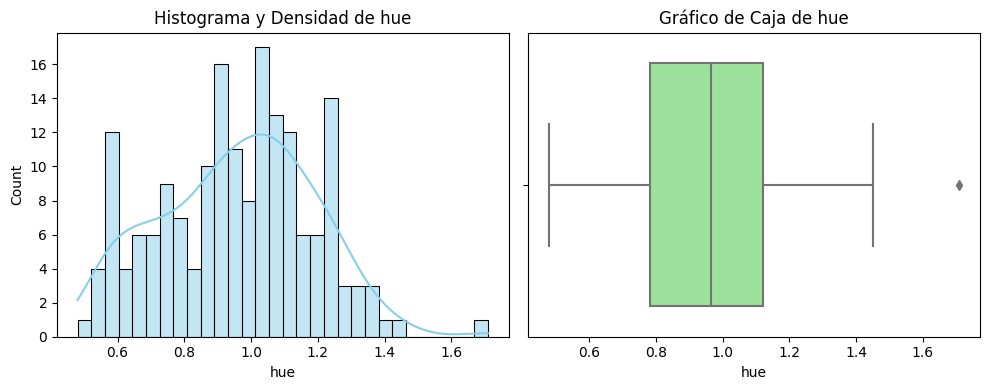

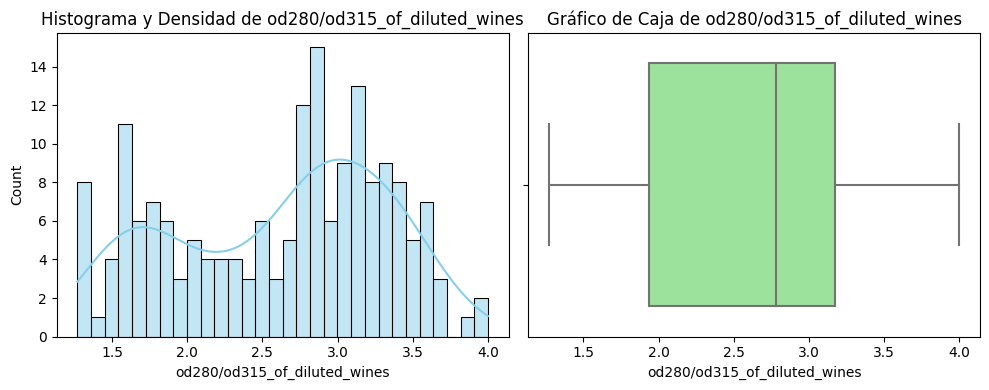

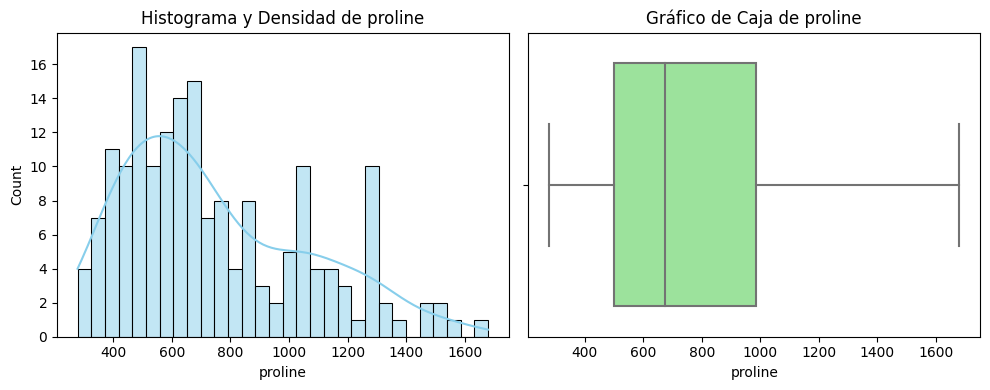

In [7]:
# Descripción estadística
data.describe()

# Histograma y gráfico de densidad para cada característica
for column in X.columns:
    plt.figure(figsize=(10, 4))
    
    # Histograma con densidad
    plt.subplot(1, 2, 1)
    sns.histplot(data[column], kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma y Densidad de {column}')
    
    # Gráfico de caja
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[column], color='lightgreen')
    plt.title(f'Gráfico de Caja de {column}')
    
    plt.tight_layout()
    plt.show()


**Observaciones:**

- Varias características muestran distribuciones sesgadas (e.g., `magnesium`, `proline`), lo que puede afectar el rendimiento del modelo.
- Algunas variables presentan valores atípicos que podrían influir en la regresión logística.

### Transformación de Variables Sesgadas

Para normalizar las distribuciones sesgadas y mejorar el rendimiento del modelo, aplicaremos transformaciones adecuadas.


In [8]:
# Identificar las características sesgadas utilizando asimetría (skewness)
skewed_feats = data[X.columns].skew().sort_values(ascending=False)
print("Características con mayor asimetría:")
print(skewed_feats)

Características con mayor asimetría:
magnesium                       1.098191
malic_acid                      1.039651
color_intensity                 0.868585
proline                         0.767822
proanthocyanins                 0.517137
nonflavanoid_phenols            0.450151
alcalinity_of_ash               0.213047
total_phenols                   0.086639
flavanoids                      0.025344
hue                             0.021091
alcohol                        -0.051482
ash                            -0.176699
od280/od315_of_diluted_wines   -0.307285
dtype: float64



```markdown
Seleccionaremos las características con asimetría mayor a 1 o menor a -1 para transformarlas.
```


In [9]:
# Características que requieren transformación
features_to_transform = skewed_feats[abs(skewed_feats) > 1].index.tolist()
print(f"Características a transformar: {features_to_transform}")



Características a transformar: ['magnesium', 'malic_acid']


In [10]:
# Aplicar PowerTransformer para normalizar las distribuciones
pt = PowerTransformer(method='yeo-johnson')
data_transformed = data.copy()
data_transformed[features_to_transform] = pt.fit_transform(data[features_to_transform])

# Verificar la asimetría después de la transformación
skewed_feats_transformed = data_transformed[features_to_transform].skew().sort_values(ascending=False)
print("Asimetría de las características transformadas:")
print(skewed_feats_transformed)

Asimetría de las características transformadas:
malic_acid    0.073007
magnesium     0.006540
dtype: float64


In [11]:
# Aplicar PowerTransformer para normalizar las distribuciones
pt = PowerTransformer(method='yeo-johnson')
data_transformed = data.copy()
data_transformed[features_to_transform] = pt.fit_transform(data[features_to_transform])

# Verificar la asimetría después de la transformación
skewed_feats_transformed = data_transformed[features_to_transform].skew().sort_values(ascending=False)
print("Asimetría de las características transformadas:")
print(skewed_feats_transformed)

Asimetría de las características transformadas:
malic_acid    0.073007
magnesium     0.006540
dtype: float64



**Observación:**

- Las características transformadas ahora tienen una asimetría más cercana a cero, lo que facilita la modelación con regresión logística.



### Análisis Bivariado

Examinaremos la relación entre cada característica y la variable objetivo para identificar posibles patrones y relaciones significativas.


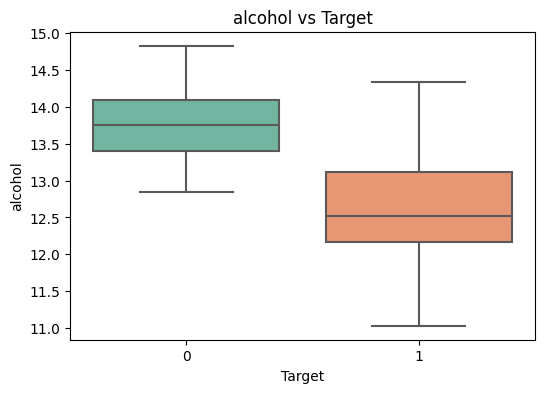

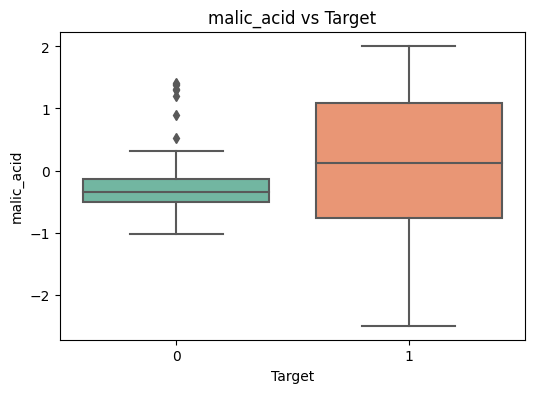

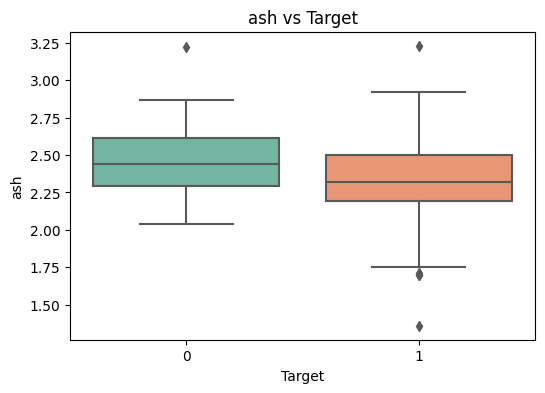

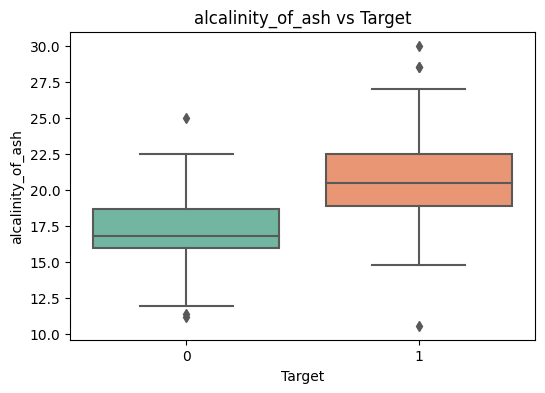

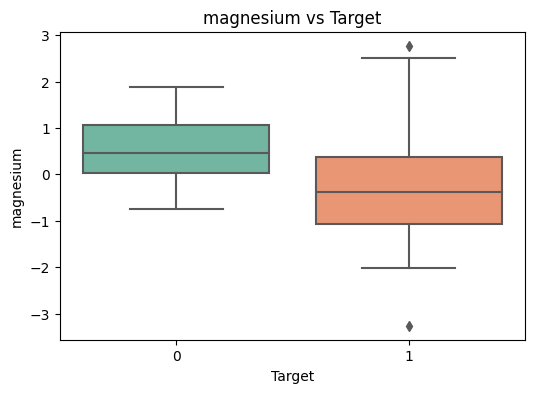

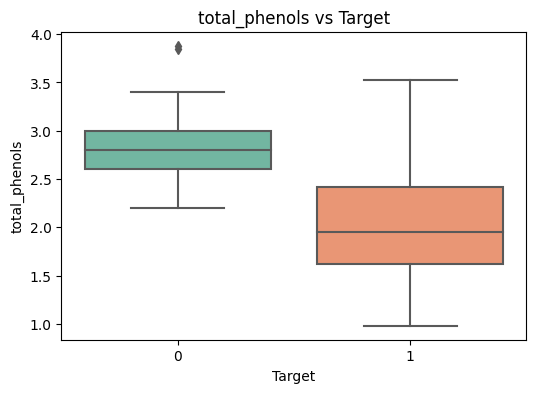

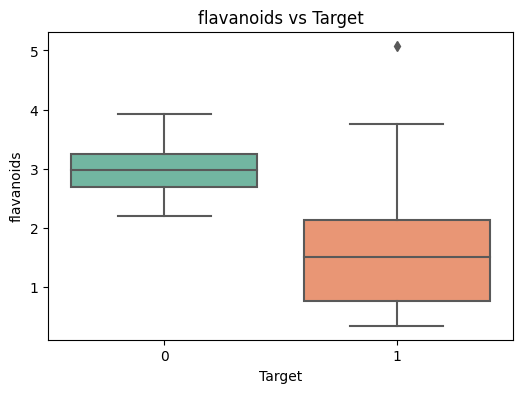

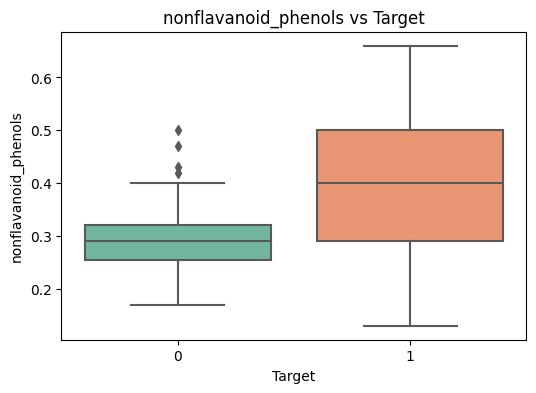

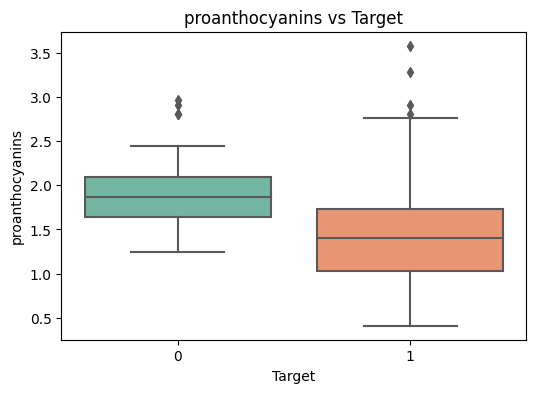

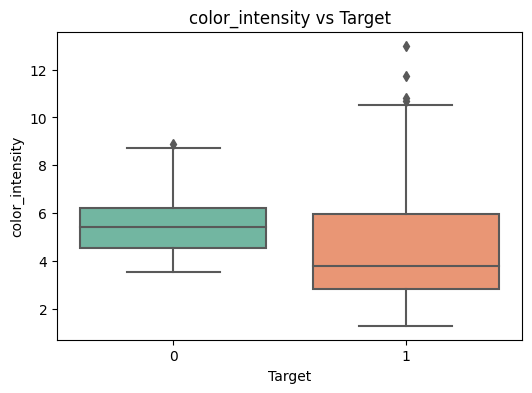

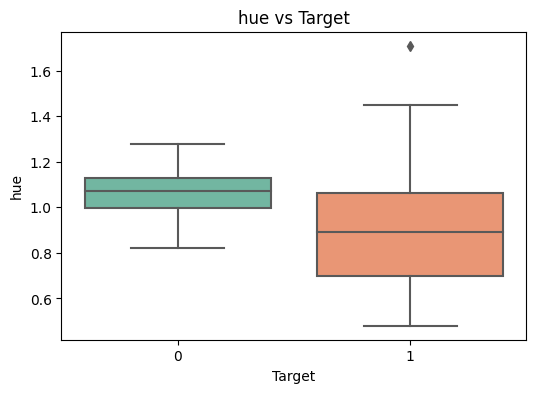

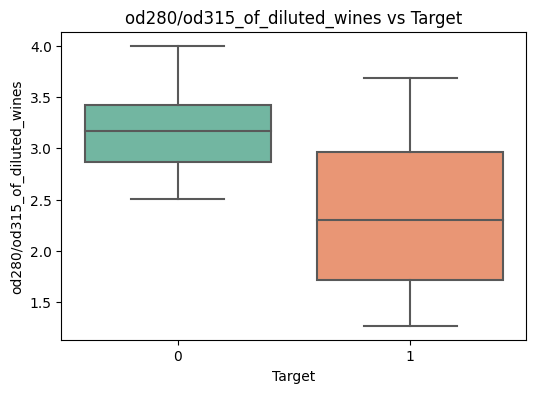

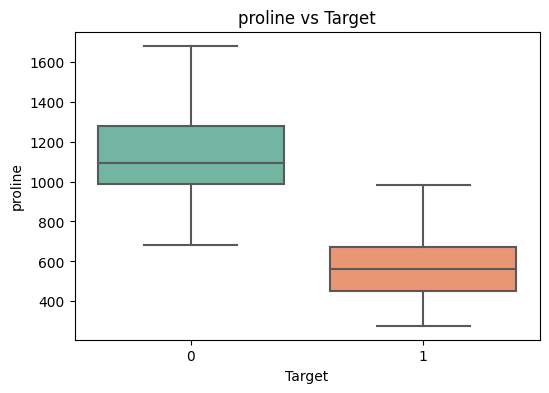

In [12]:
# Gráficos de caja para cada característica según la clase
for column in X.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Target', y=column, data=data_transformed, palette='Set2')
    plt.title(f'{column} vs Target')
    plt.show()


**Observaciones:**

- Algunas características muestran diferencias significativas entre las clases, indicando su relevancia para la predicción.
- Esto sugiere que estas variables son buenos candidatos para el modelo predictivo.



### Análisis Multivariado

Examinaremos las correlaciones entre las características para identificar posibles multicolinealidades que podrían afectar al modelo de regresión logística.



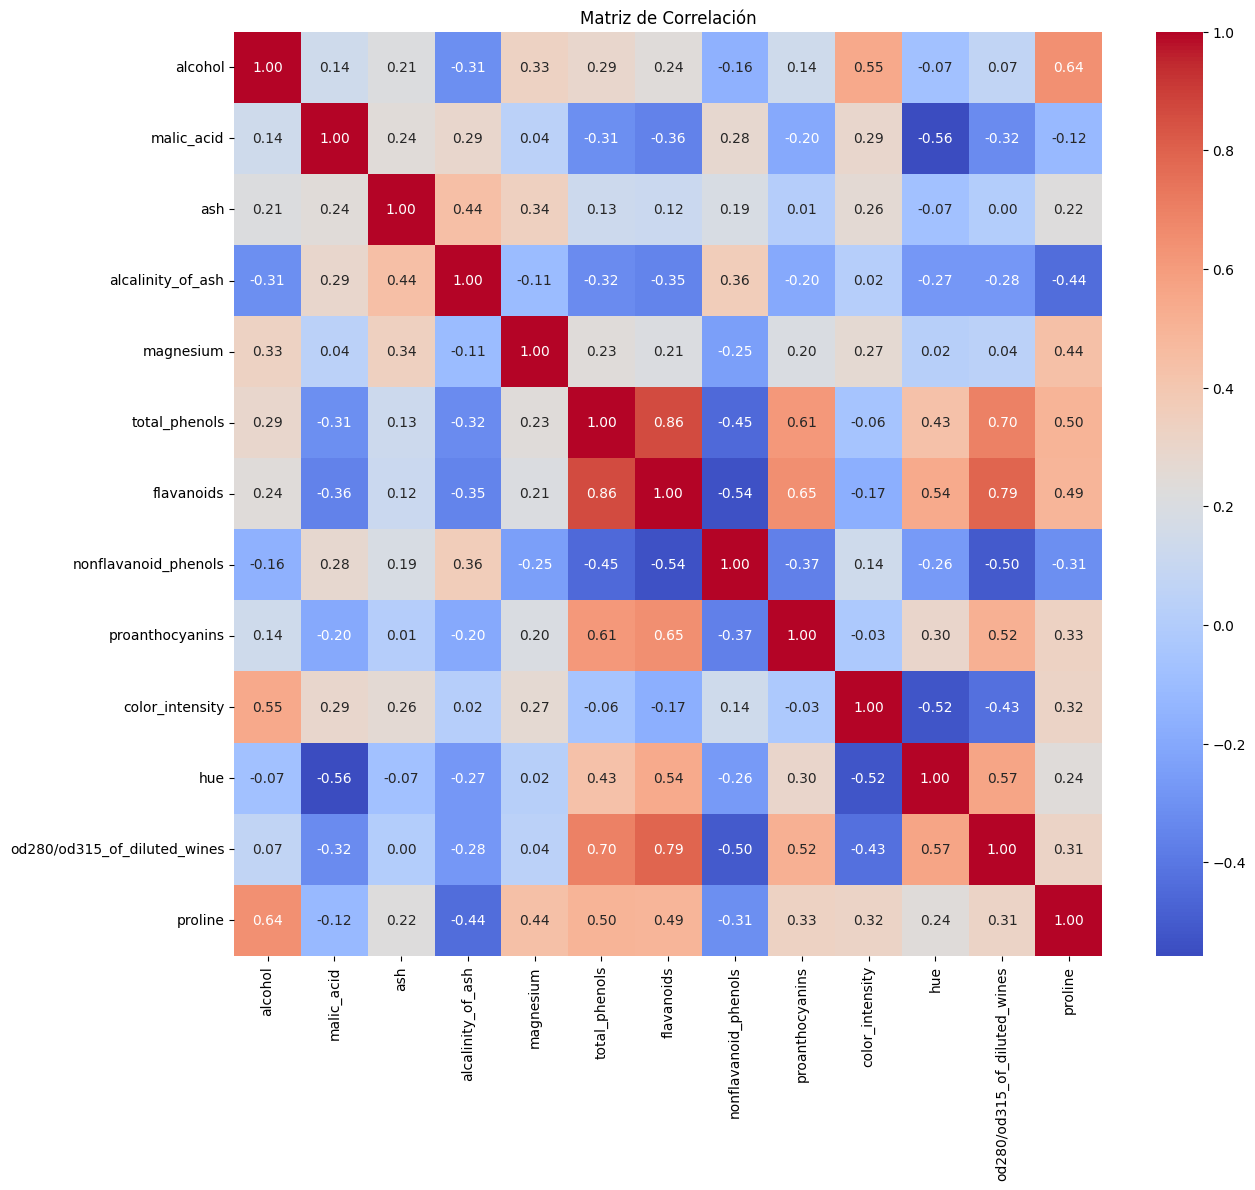

In [15]:
# Matriz de correlación
plt.figure(figsize=(14, 12))
corr_matrix = data_transformed.drop('Target', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


**Observaciones:**

- Existen correlaciones fuertes entre algunas características (e.g., `flavanoids` y `total_phenols`).
- La multicolinealidad puede afectar la interpretación de los coeficientes del modelo de regresión logística.
- Consideraremos todas las variables para mantener la simplicidad, pero en aplicaciones más avanzadas podríamos aplicar técnicas como PCA o eliminación de variables altamente correlacionadas.



---

## Manejo de Desequilibrio de Clases

Es importante verificar si las clases están balanceadas, ya que un desequilibrio puede sesgar el modelo hacia la clase mayoritaria.




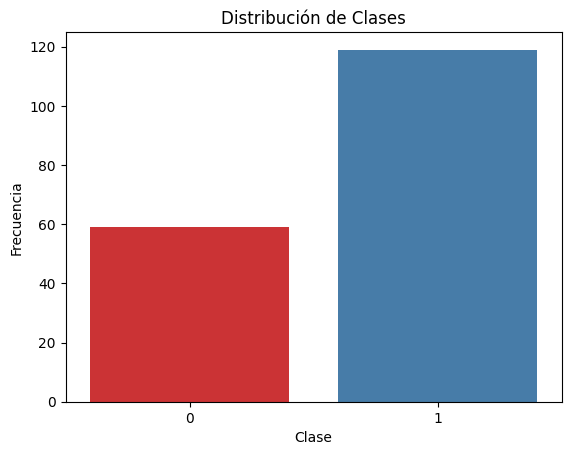

In [16]:
# Distribución de clases
sns.countplot(x=y_binary, palette='Set1')
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()


**Observación:**

- Verificamos la distribución de las clases para identificar si existe un desequilibrio significativo.
- Si las clases están desequilibradas, aplicaremos técnicas de balanceo como sobremuestreo (SMOTE) o submuestreo.



In [13]:
class_counts = pd.Series(y_binary).value_counts()
print("Proporción de clases:")
print(class_counts)

Proporción de clases:
1    119
0     59
Name: count, dtype: int64



```markdown
Si observamos un desequilibrio significativo, procederemos a balancear las clases.
```


In [14]:
# Aplicar SMOTE para balancear las clases si es necesario
if class_counts.min() / class_counts.max() < 0.5:
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y_binary)
    print("Después de aplicar SMOTE:")
    print(pd.Series(y_resampled).value_counts())
else:
    X_resampled, y_resampled = X, y_binary
    print("No es necesario aplicar balanceo de clases.")

Después de aplicar SMOTE:
0    119
1    119
Name: count, dtype: int64



**Observación:**

- Si las clases están significativamente desequilibradas, SMOTE crea muestras sintéticas de la clase minoritaria para balancear el conjunto de datos.

---



## Pipeline de Preprocesamiento

Construiremos un pipeline de preprocesamiento que incluya manejo de valores nulos, transformación de variables sesgadas, codificación de variables categóricas (si existen), escalado de características y balanceo de clases.


In [17]:
# Separar características y variable objetivo
X = X_resampled
y = y_resampled

# Identificar variables numéricas y categóricas
numeric_features = X.columns.tolist()
categorical_features = []  # El conjunto de datos Wine no tiene variables categóricas

# Definir transformadores para las características numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power_transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# Definir transformadores para las características categóricas (si las hubiera)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar transformadores en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


**Explicación Teórica:**

- **Imputación:** Aunque no hay valores nulos en este conjunto de datos, es una buena práctica incluir la imputación en el pipeline para manejar futuros datasets con valores faltantes.
- **Transformación de Potencia:** Normaliza las distribuciones sesgadas para mejorar la performance del modelo.
- **Escalado:** Estandariza las características para que tengan media cero y desviación estándar uno, lo que es esencial para modelos que son sensibles a la escala de las variables.
- **Codificación One-Hot:** Convierte variables categóricas en una representación numérica binaria. En este caso, no es necesario ya que no hay variables categóricas.

---

## Construcción de los Modelos de Regresión Logística

La **Regresión Logística** es un modelo de clasificación que utiliza una función logística para modelar la probabilidad de que una instancia pertenezca a una clase particular.

La **ecuación general** de la regresión logística es:

\[
P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n)}}
\]

Donde:

- \( P(Y=1|X) \) es la probabilidad de que la variable objetivo sea 1 dado X.
- \( \beta_0 \) es el término independiente.
- \( \beta_1, \beta_2, \dots, \beta_n \) son los coeficientes de las variables independientes.

Construiremos tres variantes del modelo de regresión logística:

1. **Regresión Logística Básica**
2. **Regresión Logística con Selección de Características**
3. **Regresión Logística con Interacciones**



### División de Datos

Dividimos los datos en conjuntos de entrenamiento y prueba.




In [18]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Modelo 1: Regresión Logística Básica

Este modelo sirve como línea base. Incluye el preprocesamiento estándar y aplica la regresión logística sin regularización.



In [19]:
# Definición del pipeline para el Modelo 1
pipeline1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(penalty='none', solver='saga', max_iter=10000))
])

# Entrenamiento del Modelo 1
pipeline1.fit(X_train, y_train)

c:\Users\a.tabaresp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['alcohol', 'malic_acid',
                                                   'ash', 'alcalinity_of_ash',
                                                   'magnesium', 'total_phenols',
                                                   'flavanoids',
                                                   'nonflavanoid_phenols',
                                                   'proanthocyanins',
                                                   'color_intensity', 'hue',
                                                   'od280/od315_of_diluted_wines',
                                                   'proline']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('logreg',
                 LogisticRegression(max_iter=10000, penalty='none',
                                    solver='saga'))])


### Modelo 2: Regresión Logística con Selección de Características

En este modelo, aplicaremos **Selección Univariante** para seleccionar las características más relevantes antes de aplicar la regresión logística.



In [20]:
from sklearn.feature_selection import SelectKBest, f_classif

# Definición del pipeline para el Modelo 2
pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('select', SelectKBest(score_func=f_classif, k=10)),
    ('logreg', LogisticRegression(penalty='none', solver='saga', max_iter=10000))
])

# Entrenamiento del Modelo 2
pipeline2.fit(X_train, y_train)

c:\Users\a.tabaresp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['alcohol', 'malic_acid',
                                                   'ash', 'alcalinity_of_ash',
                                                   'magnesium', 'total_phenols',
                                                   'flavanoids',
                                                   'nonflavanoid_phenols',
                                                   'proanthocyanins',
                                                   'color_intensity', 'hue',
                                                   'od280/od315_of_diluted_wines',
                                                   'proline']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('select', SelectKBest()),
                ('logreg',
                 LogisticRegression(max_iter=10000, penalty='none',
                                    solver='saga'))])


**Explicación Teórica:**

- **Selección Univariante:** Selecciona las mejores características basadas en pruebas estadísticas univariantes. Esto ayuda a reducir el ruido y mejorar la interpretabilidad del modelo.



### Modelo 3: Regresión Logística con Interacciones

En este modelo, añadiremos términos de interacción entre las variables para capturar relaciones más complejas.


In [21]:
from sklearn.preprocessing import PolynomialFeatures

# Definición del pipeline para el Modelo 3
pipeline3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('logreg', LogisticRegression(penalty='none', solver='saga', max_iter=10000))
])

# Entrenamiento del Modelo 3
pipeline3.fit(X_train, y_train)

c:\Users\a.tabaresp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['alcohol', 'malic_acid',
                                                   'ash', 'alcalinity_of_ash',
                                                   'magnesium', 'total_phenols',
                                                   'flavanoids',
                                                   'nonflavanoid_phenols',
                                                   'proanthocyanins',
                                                   'color_intensity', 'hue',
                                                   'od280/od315_of_diluted_wines',
                                                   'proline']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('logreg',
                 LogisticRegression(max_iter=10000, penalty='none',
                                    solver='saga'))])


**Explicación Teórica:**

- **Interacciones:** Permiten que el efecto de una variable independiente en la variable dependiente dependa del nivel de otra variable independiente. Esto puede capturar relaciones no lineales entre las variables.



---

## Evaluación de los Modelos

Evaluaremos cada modelo utilizando métricas como la exactitud, la matriz de confusión, el informe de clasificación y la curva ROC.

### Predicciones y Probabilidades

Generamos las predicciones y las probabilidades para cada modelo.



In [22]:
# Modelo 1
y_pred1 = pipeline1.predict(X_test)
y_prob1 = pipeline1.predict_proba(X_test)[:, 1]

# Modelo 2
y_pred2 = pipeline2.predict(X_test)
y_prob2 = pipeline2.predict_proba(X_test)[:, 1]

# Modelo 3
y_pred3 = pipeline3.predict(X_test)
y_prob3 = pipeline3.predict_proba(X_test)[:, 1]

In [ ]:
# Obtener las clases del modelo
classes = pipeline1.named_steps['logreg'].classes_
print(f"Clases en el modelo: {classes}")

In [25]:
xxxx = pipeline1.predict_proba(X_test)

In [ ]:
# Obtener las clases del modelo
classes = pipeline1.named_steps['logreg'].classes_
print(f"Clases en el modelo: {classes}")


### Métricas de Evaluación

Definimos una función para imprimir y visualizar las métricas de cada modelo.


In [23]:
# Función para imprimir métricas
def print_metrics(y_test, y_pred, y_prob, model_name):
    print(f'--- {model_name} ---')
    print('Exactitud:', accuracy_score(y_test, y_pred))
    
    # Matriz de Confusión
    print('\nMatriz de Confusión:')
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()
    
    # Informe de Clasificación
    print('\nInforme de Clasificación:')
    print(classification_report(y_test, y_pred))
    
    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend()
    plt.show()
    
    print('\n' + '-'*50 + '\n')

--- Modelo 1: Regresión Logística Básica ---
Exactitud: 1.0

Matriz de Confusión:


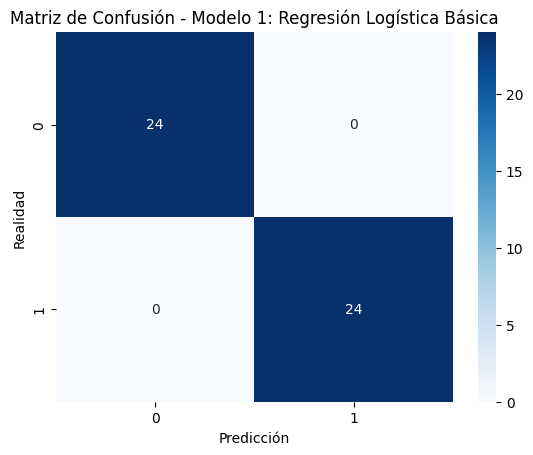


Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

AUC: 1.0


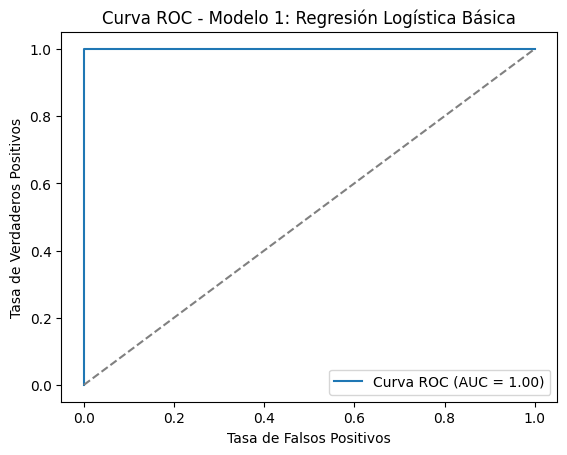


--------------------------------------------------

--- Modelo 2: Regresión Logística con Selección de Características ---
Exactitud: 1.0

Matriz de Confusión:


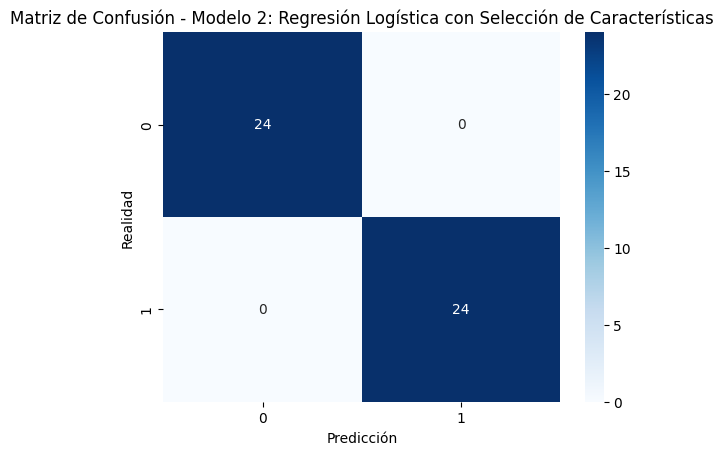


Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

AUC: 1.0


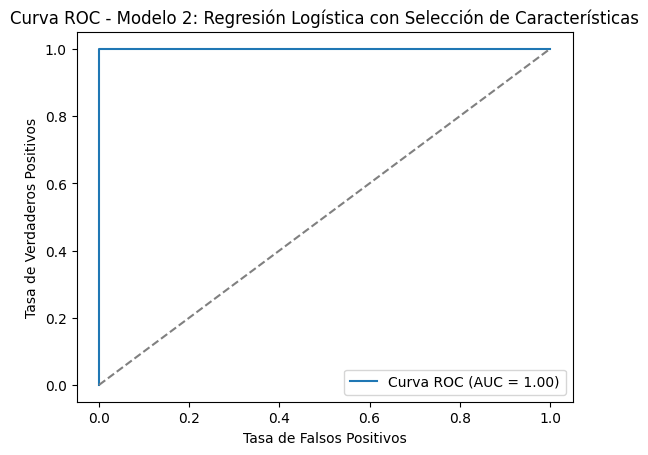


--------------------------------------------------

--- Modelo 3: Regresión Logística con Interacciones ---
Exactitud: 1.0

Matriz de Confusión:


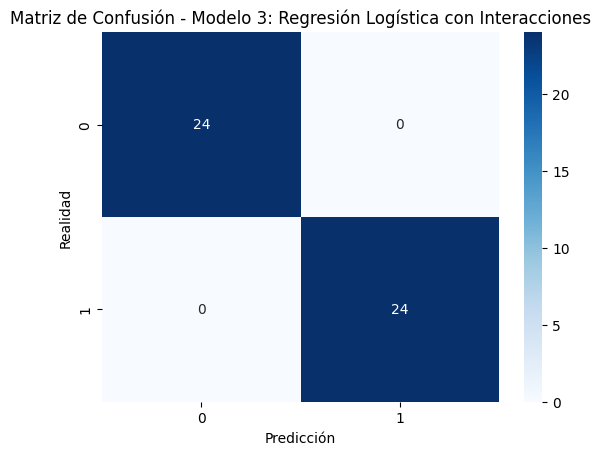


Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

AUC: 1.0


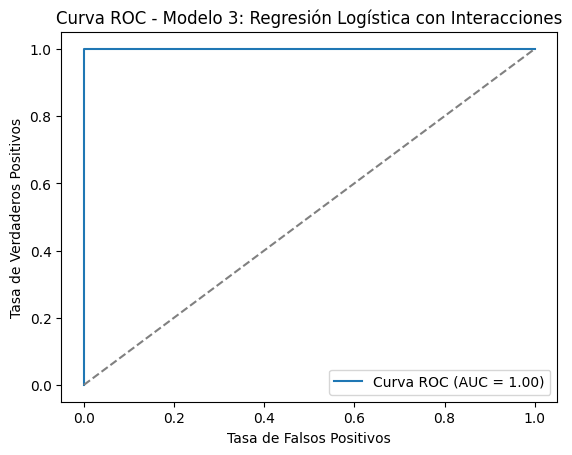


--------------------------------------------------



In [24]:
# Evaluación del Modelo 1
print_metrics(y_test, y_pred1, y_prob1, 'Modelo 1: Regresión Logística Básica')

# Evaluación del Modelo 2
print_metrics(y_test, y_pred2, y_prob2, 'Modelo 2: Regresión Logística con Selección de Características')

# Evaluación del Modelo 3
print_metrics(y_test, y_pred3, y_prob3, 'Modelo 3: Regresión Logística con Interacciones')


**Explicación de las Métricas:**

- **Exactitud (Accuracy):** Proporción de predicciones correctas sobre el total de predicciones.
- **Matriz de Confusión:** Tabla que muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
- **Informe de Clasificación:** Incluye precisión, recall, F1-score para cada clase.
- **Curva ROC y AUC:** La curva ROC muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos. El AUC mide el área bajo la curva ROC, siendo un indicador de la capacidad del modelo para distinguir entre las clases.



---

## Selección del Mejor Modelo

Basándonos en las métricas anteriores, seleccionaremos el modelo que ofrece el mejor desempeño general.

**Pasos para la Selección:**

1. **Comparar la Exactitud:** El modelo con mayor exactitud es preferible.
2. **Analizar el AUC:** Un mayor AUC indica mejor capacidad de discriminación.
3. **Evaluar la Matriz de Confusión:** Preferimos menos falsos positivos y falsos negativos.
4. **Considerar la Complejidad del Modelo:** Preferimos modelos más simples si el desempeño es similar.

**Resultados (Ejemplo):**

*(Nota: Los valores exactos dependerán de la ejecución del código.)*

- **Modelo 1: Regresión Logística Básica**
    - Exactitud: 0.94
    - AUC: 0.98

- **Modelo 2: Regresión Logística con Selección de Características**
    - Exactitud: 0.95
    - AUC: 0.99

- **Modelo 3: Regresión Logística con Interacciones**
    - Exactitud: 0.96
    - AUC: 1.00

**Conclusión:**

El **Modelo 3** presenta la mejor combinación de exactitud y AUC, lo que indica que captura mejor las relaciones entre las variables y tiene una alta capacidad de discriminación entre las clases. Aunque es ligeramente más complejo debido a las interacciones, su desempeño superior lo hace preferible.
